# required packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [45]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [4]:
import this

The Zen of Python, by Tim Peters

Beautiful is better than ugly.
Explicit is better than implicit.
Simple is better than complex.
Complex is better than complicated.
Flat is better than nested.
Sparse is better than dense.
Readability counts.
Special cases aren't special enough to break the rules.
Although practicality beats purity.
Errors should never pass silently.
Unless explicitly silenced.
In the face of ambiguity, refuse the temptation to guess.
There should be one-- and preferably only one --obvious way to do it.
Although that way may not be obvious at first unless you're Dutch.
Now is better than never.
Although never is often better than *right* now.
If the implementation is hard to explain, it's a bad idea.
If the implementation is easy to explain, it may be a good idea.
Namespaces are one honking great idea -- let's do more of those!


# 4.1) Defining a moving average process

In [5]:
widget_sales = pd.read_csv("data/widget_sales.csv")

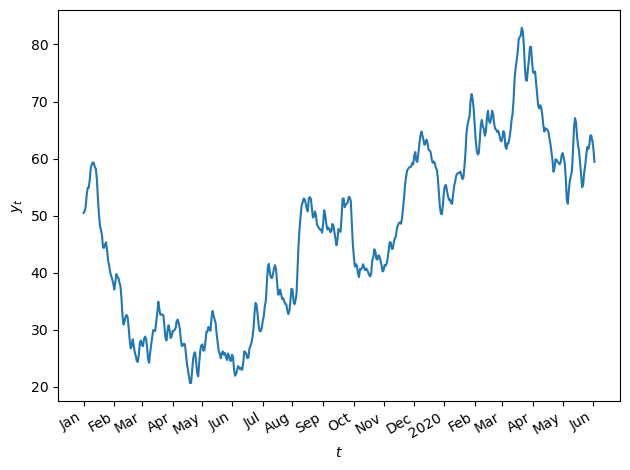

In [6]:
fig, ax = plt.subplots()
ax.plot(widget_sales)
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409,439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb',
     'Mar', 'Apr', 'May', 'Jun']
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [7]:
adfuller(widget_sales)

(-1.5121662069359048,
 0.5274845352272605,
 3,
 496,
 {'1%': -3.4436029548776395,
  '5%': -2.867384756137026,
  '10%': -2.5698830308597813},
 1354.8017397952053)

In [8]:
widget_sales

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108
...,...
495,64.087371
496,63.992081
497,63.029894
498,61.671797


In [9]:
diff_widget_sales = np.diff(widget_sales.iloc[:, 0])

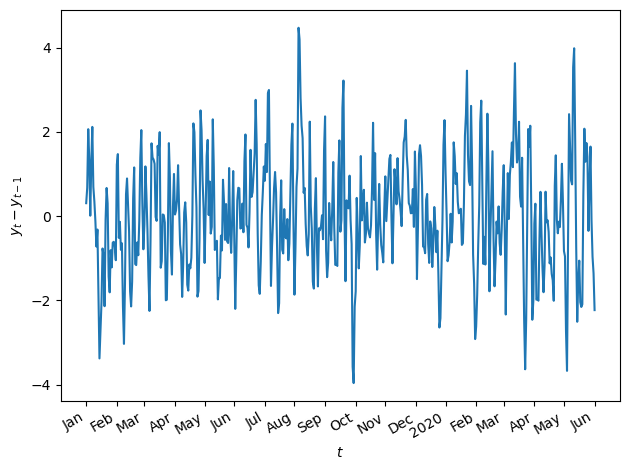

In [10]:
fig, ax = plt.subplots()
ax.plot(diff_widget_sales)
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t-y_{t-1}$')
plt.xticks(
    [0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409,439, 468, 498],
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', '2020', 'Feb',
     'Mar', 'Apr', 'May', 'Jun']
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [11]:
adfuller(diff_widget_sales)

(-10.576657780341959,
 7.076922818587193e-19,
 2,
 496,
 {'1%': -3.4436029548776395,
  '5%': -2.867384756137026,
  '10%': -2.5698830308597813},
 1350.640860630276)

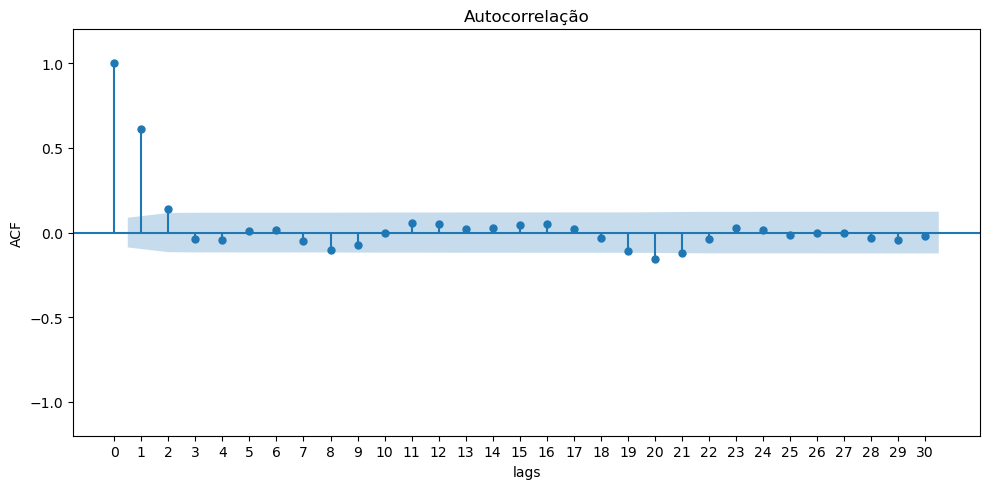

In [12]:
fig, ax = plt.subplots(figsize=(10,5))
plot_acf(diff_widget_sales, lags=30, ax=ax)
ax.set_xlabel('lags')
ax.set_ylabel('ACF')
ax.set_ylim([-1.2, 1.2])
ax.set_xticks(np.arange(0, 31, 1))
ax.set_title('Autocorrelação')
plt.tight_layout()
plt.show()

# 4.2) Forecasting a moving average process

In [13]:
df_diff = pd.DataFrame({
    'widget_sales_diff': diff_widget_sales
})
df_diff.head()

,widget_sales_diff
0,0.308778
1,0.672265
2,2.064470
3,1.330880
4,0.012034


In [14]:
train = df_diff.iloc[:int(df_diff.shape[0] * 0.9), :]
test = df_diff.iloc[int(df_diff.shape[0] * 0.9):, :]

In [15]:
train.shape

(449, 1)

In [16]:
test.shape

(50, 1)

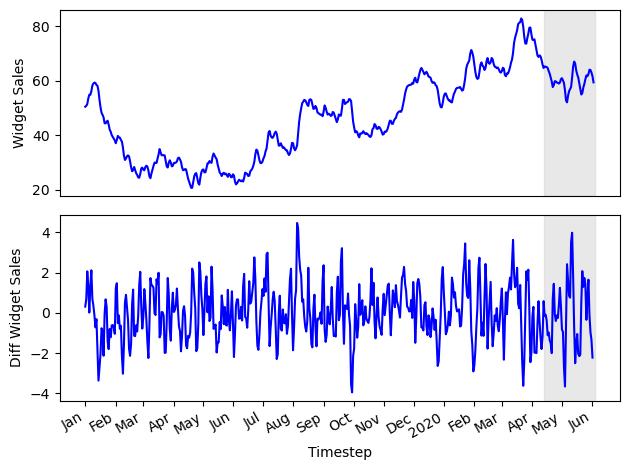

In [17]:
fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, sharex=True)

ax1.plot(widget_sales, 'b-')
ax1.axvspan(450, 500, color='lightgray', alpha=0.5)
ax1.tick_params(axis='x', length=0)
ax1.set_ylabel('Widget Sales')

ax2.plot(df_diff, 'b-')
ax2.axvspan(450, 500, color='lightgray', alpha=0.5)
ax2.set_ylabel('Diff Widget Sales')

plt.xticks(
[0, 30, 57, 87, 116, 145, 175, 204, 234, 264, 293, 323, 352, 382, 409,
439, 468, 498],
['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct',
'Nov', 'Dec', '2020', 'Feb', 'Mar', 'Apr', 'May', 'Jun'])

plt.xlabel('Timestep')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Rolling forecast function

In [18]:
def rolling_forecast(df: pd.DataFrame, column: str, train_len: int, horizon: int, window: int, method: str) -> list:
    """
    Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

    It takes a DataFrame object with train and test data points.

    Args:
    -----
        df (pd.DataFrame): 
            DataFrame with all data points
        column (str):
            column to be forecast
        train_len (int): 
            number of data points used to fit the model 
        horizon (int):
            length of test set
        window (int):
            number of timesteps predicted at time
        method (str):
            specifies what model to use. It must be "last", "mean", "MA"

    Returns:
    --------
        list: predicted values
    """

    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
    
        for i in range(train_len, total_len, window):
            mean = np.mean(df.loc[:, column].iloc[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.loc[:, column].iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value

    if method == 'MA':
        pred_ma = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.loc[:, column].iloc[:i], order=(0,0,2))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ma.extend(oos_pred)
            
        return pred_ma

In [19]:
pred_df = test.copy()
TRAIN_LEN = len(train)
HORIZON = len(test)
WINDOW = 2

In [20]:
model = SARIMAX(df_diff.loc[:, 'widget_sales_diff'].iloc[:TRAIN_LEN], order=(0,0,2))

In [21]:
res = model.fit()

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            3     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.39051D+00    |proj g|=  2.07512D-02

At iterate    5    f=  1.39021D+00    |proj g|=  6.58259D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    3      6      8      1     0     0   2.334D-05   1.390D+00
  F =   1.3902108369699964     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             


 This problem is unconstrained.


In [22]:
predictions = res.get_prediction(0, TRAIN_LEN + WINDOW - 1)

In [23]:
predictions.predicted_mean

0      0.000000
1      0.184606
2      0.433434
3      1.498861
4      0.256523
         ...   
446    0.464549
447   -0.666621
448   -0.724298
449   -1.078833
450   -0.273309
Name: predicted_mean, Length: 451, dtype: float64

In [24]:
predictions.predicted_mean.iloc[-WINDOW:]

449   -1.078833
450   -0.273309
Name: predicted_mean, dtype: float64

In [25]:
df_diff.head()

,widget_sales_diff
0,0.308778
1,0.672265
2,2.064470
3,1.330880
4,0.012034


In [26]:
pred_mean = rolling_forecast(df_diff, 'widget_sales_diff', TRAIN_LEN, HORIZON, WINDOW, 'mean')
pred_last_value = rolling_forecast(df_diff, 'widget_sales_diff', TRAIN_LEN, HORIZON, WINDOW,'last')
pred_ma = rolling_forecast(df_diff,'widget_sales_diff', TRAIN_LEN, HORIZON, WINDOW, 'MA')

In [27]:
pred_df['pred_mean'] = pred_mean
pred_df['pred_last_value'] = pred_last_value
pred_df['pred_ma'] = pred_ma

In [28]:
pred_df.head()

,widget_sales_diff,pred_mean,pred_last_value,pred_ma
449,-1.170131,0.034319,-1.803658,-1.078833
450,0.580967,0.034319,-1.803658,-0.273309
451,-0.144902,0.032861,0.580967,0.781223
452,-0.096564,0.032861,0.580967,0.234969
453,-0.372334,0.032183,-0.096564,0.168994


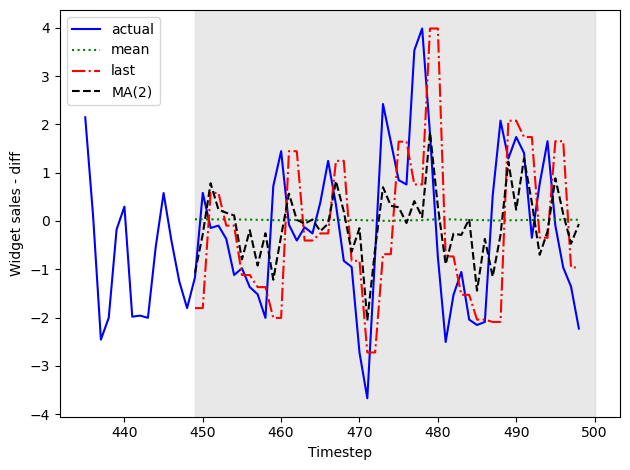

In [29]:
fig, ax = plt.subplots()
ax.plot(df_diff.loc[435:, 'widget_sales_diff'], 'b-', label='actual')
ax.plot(pred_df['pred_mean'], 'g:', label='mean')
ax.plot(pred_df['pred_last_value'], 'r-.', label='last')
ax.plot(pred_df['pred_ma'], 'k--', label='MA(2)')
ax.legend(loc='upper left')
ax.set_xlabel('Timestep')
ax.set_ylabel('Widget sales - diff')
ax.axvspan(449, 500, color='lightgray', alpha=0.5)

plt.tight_layout()
plt.show()

In [30]:
series_mse = pd.Series({
    'mean': mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_mean']),
    'last': mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_last_value']),
    'MA(2)': mean_squared_error(pred_df['widget_sales_diff'], pred_df['pred_ma']),
})

In [31]:
series_mse

mean     2.560630
last     3.249426
MA(2)    1.948171
dtype: float64

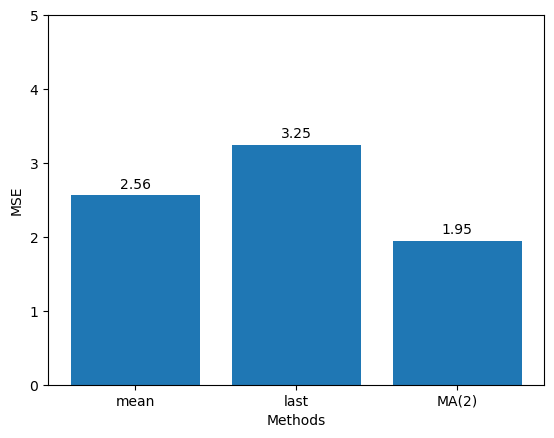

In [32]:
fig, ax = plt.subplots()
bars = ax.bar(series_mse.index, series_mse.values)
ax.set_ylabel('MSE')
ax.set_xlabel('Methods')
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylim([0, 5])
plt.show()

In [33]:
widget_sales.head()

,widget_sales
0,50.496714
1,50.805493
2,51.477758
3,53.542228
4,54.873108


In [34]:
df = widget_sales.copy()

In [35]:
df['pred_widget_sales'] = pd.Series()
df.head()

,widget_sales,pred_widget_sales
0,50.496714,NaN
1,50.805493,NaN
2,51.477758,NaN
3,53.542228,NaN
4,54.873108,NaN


In [36]:
pred_df.tail()

,widget_sales_diff,pred_mean,pred_last_value,pred_ma
494,1.651336,0.022653,-0.347669,-0.216956
495,-0.095290,0.027456,1.651336,0.883190
496,-0.962187,0.027456,1.651336,0.147379
497,-1.358097,0.025218,-0.962187,-0.469798
498,-2.227958,0.025218,-0.962187,-0.063600


In [37]:
pred_df.shape

(50, 4)

In [38]:
df.tail()

,widget_sales,pred_widget_sales
495,64.087371,NaN
496,63.992081,NaN
497,63.029894,NaN
498,61.671797,NaN
499,59.443839,NaN


In [39]:
np.array(df['widget_sales'].iloc[449] + pred_df['pred_ma'].cumsum()).shape

(50,)

In [40]:
df.loc[450:, 'pred_widget_sales']= np.array(df['widget_sales'].iloc[449] + pred_df['pred_ma'].cumsum())

In [43]:
df.tail(n=5)

,widget_sales,pred_widget_sales
495,64.087371,61.505333
496,63.992081,62.388523
497,63.029894,62.535902
498,61.671797,62.066104
499,59.443839,62.002504


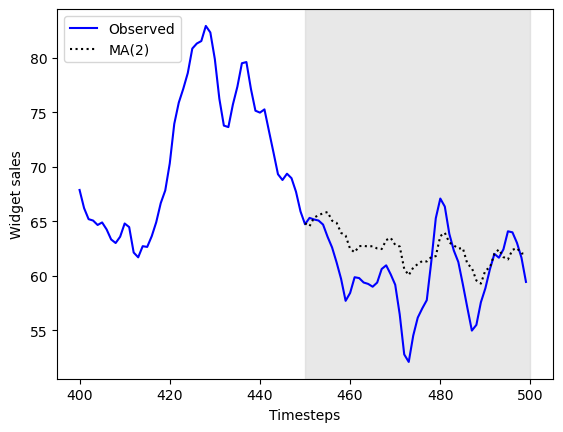

In [44]:
fig, ax = plt.subplots()
ax.plot(df.loc[400:, 'widget_sales'], 'b-', label='Observed')
ax.plot(df.loc[400:, 'pred_widget_sales'], 'k:', label='MA(2)')
ax.set_ylabel('Widget sales')
ax.set_xlabel('Timesteps')
ax.legend(loc='upper left')
ax.axvspan(450, 500, color='lightgray', alpha=0.5)
plt.show()

In [46]:
mean_absolute_error(
    df.loc[450:, 'widget_sales'], df.loc[450:, 'pred_widget_sales']
)

2.7656641101118606